# Turismo no Brasil (2015–2024): análise e visualização de dados com Python

**Projeto G2 · Tema 18** · Análise e Visualização de Dados com Python

## 1. Introdução

O turismo é uma atividade econômica que mexe com empregos, serviços, infraestrutura urbana e
desenvolvimento regional. O fluxo de turistas, porém, não é constante: muda conforme a época do ano, os
eventos, o clima e a localização geográfica.

Neste notebook, vamos investigar uma base simulada de turismo no Brasil entre **2015 e 2024** para
responder às perguntas orientadoras do projeto:

1. Quais cidades recebem mais turistas?
2. Existem períodos de alta temporada?
3. Quais regiões movimentam mais recursos?
4. Qual o impacto econômico do turismo?
5. Existem diferenças regionais relevantes?
6. Quais destinos apresentaram maior crescimento?
7. Como o turismo evoluiu ao longo do tempo?

## 2. Contextualização do turismo

A análise de dados turísticos permite identificar **tendências de viagem**, **destinos mais procurados** e
**padrões de consumo**. Para gestores públicos e empresas do setor, isso apoia decisões como onde investir
em infraestrutura, quando reforçar a capacidade hoteleira e quais regiões merecem campanhas de atração.

## 3. Explicação da base de dados

Arquivo: `simulacao_turismo_brasil.csv` (dataset **simulado**, fornecido para fins educacionais).

| Coluna | Descrição |
| --- | --- |
| `ano` | Ano da pesquisa |
| `mes` | Mês da pesquisa |
| `data` | Data de referência |
| `regiao` | Região do Brasil |
| `uf` | Estado |
| `cidade` | Cidade turística |
| `turistas` | Quantidade de turistas |
| `turistas_estrangeiros` | Quantidade de turistas internacionais |
| `ocupacao_hoteleira` | Taxa de ocupação |
| `gasto_medio` | Gasto médio por turista |
| `faturamento_turismo` | Receita do setor |
| `eventos_realizados` | Quantidade de eventos |
| `temperatura_media` | Temperatura média |
| `nivel_temporada` | Baixa, Média ou Alta |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.2f}".format

# Pasta onde os gráficos serão salvos (usados na página index.html)
PASTA_IMAGENS = Path("../imagens") if Path("../imagens").exists() else Path("imagens")
PASTA_IMAGENS.mkdir(exist_ok=True)


def salvar_grafico(nome_arquivo):
    """Salva a figura atual do Matplotlib na pasta de imagens."""
    plt.savefig(PASTA_IMAGENS / nome_arquivo, dpi=150, bbox_inches="tight")

## 4. Leitura dos dados

In [2]:
candidatos = [
    Path("../dados/simulacao_turismo_brasil.csv"),   # rodando dentro de notebooks/
    Path("dados/simulacao_turismo_brasil.csv"),      # rodando na raiz do projeto
    Path("simulacao_turismo_brasil.csv"),            # arquivo na mesma pasta (ex.: Google Colab)
]
caminho_csv = next((c for c in candidatos if c.exists()), None)
if caminho_csv is None:
    raise FileNotFoundError(
        "CSV não encontrado. Coloque simulacao_turismo_brasil.csv em dados/ "
        "(ou envie o arquivo para o Colab)."
    )

# sep=None detecta automaticamente se o separador é vírgula ou ponto e vírgula
bruto = pd.read_csv(caminho_csv, sep=None, engine="python", encoding="utf-8-sig")
print(f"Linhas: {bruto.shape[0]:,} | Colunas: {bruto.shape[1]}")
bruto.head()

Linhas: 4,440 | Colunas: 14


,ano,mes,data,regiao,uf,cidade,turistas,turistas_estrangeiros,ocupacao_hoteleira,gasto_medio,faturamento_turismo,eventos_realizados,temperatura_media,nivel_temporada
0,2015,1,2015-01-01,Norte,AM,Manaus,233689,47282,68.73,696.92,"6,122,437.53",6,25.80,Média
1,2015,1,2015-01-01,Norte,PA,Belém,40837,41637,90.38,806.78,"122,192,256.23",9,29.90,Baixa
2,2015,1,2015-01-01,Norte,PA,Santarém,393947,72315,89.25,"1,073.61","21,025,374.00",7,21.90,Baixa
3,2015,1,2015-01-01,Norte,RO,Porto Velho,278109,30614,91.51,237.15,"76,011,333.17",8,25.50,Alta
4,2015,1,2015-01-01,Norte,TO,Palmas,282562,73139,76.32,791.34,"166,329,202.46",5,28.60,Alta


In [3]:
bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ano                    4440 non-null   int64  
 1   mes                    4440 non-null   int64  
 2   data                   4440 non-null   str    
 3   regiao                 4440 non-null   str    
 4   uf                     4440 non-null   str    
 5   cidade                 4440 non-null   str    
 6   turistas               4440 non-null   int64  
 7   turistas_estrangeiros  4440 non-null   int64  
 8   ocupacao_hoteleira     4440 non-null   float64
 9   gasto_medio            4440 non-null   float64
 10  faturamento_turismo    4440 non-null   float64
 11  eventos_realizados     4440 non-null   int64  
 12  temperatura_media      4440 non-null   float64
 13  nivel_temporada        4440 non-null   str    
dtypes: float64(4), int64(5), str(5)
memory usage: 636.5 KB


## 5. Limpeza e preparação

Primeiro, um diagnóstico: tipos, valores nulos, duplicatas e estatísticas descritivas.

In [4]:
base = bruto.copy()
base.columns = [coluna.strip().lower() for coluna in base.columns]

print("Valores nulos por coluna:")
print(base.isna().sum()[base.isna().sum() > 0].to_string() or "nenhum")
print(f"\nLinhas duplicadas: {base.duplicated().sum()}")
base.describe().T

Valores nulos por coluna:
Series([], )

Linhas duplicadas: 0


,count,mean,std,min,25%,50%,75%,max
ano,"4,440.00","2,019.50",2.87,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
mes,"4,440.00",6.50,3.45,1.00,3.75,6.50,9.25,12.00
turistas,"4,440.00","256,749.77","142,686.32","10,053.00","134,104.25","258,585.00","380,092.25","499,896.00"
turistas_estrangeiros,"4,440.00","39,943.76","22,775.08","1,022.00","20,489.25","39,543.50","59,734.25","79,946.00"
ocupacao_hoteleira,"4,440.00",60.43,20.35,25.01,42.81,60.83,78.38,94.99
gasto_medio,"4,440.00",675.71,306.27,150.01,410.58,676.88,940.41,"1,199.80"
faturamento_turismo,"4,440.00","99,825,528.05","57,263,559.55","1,026,092.86","50,487,296.31","98,628,920.82","150,504,181.67","199,984,624.83"
eventos_realizados,"4,440.00",9.91,3.10,1.00,8.00,10.00,12.00,23.00
temperatura_media,"4,440.00",24.90,4.02,9.20,22.20,24.90,27.60,40.30


Decisões de tratamento:

- **Duplicatas:** removidas.
- **Nulos em colunas essenciais** (`ano`, `mes`, `cidade`, `turistas`, `faturamento_turismo`): linha descartada.
- **Nulos nas demais colunas numéricas:** preenchidos com a **mediana da própria cidade** (menos sensível a
  valores extremos do que a média e respeita o perfil de cada destino).
- **Texto:** espaços removidos, UF em maiúsculas e nível de temporada padronizado (Baixa, Média, Alta).
- **Data:** padronizada para o primeiro dia de cada mês.

In [5]:
colunas_numericas = [
    "turistas", "turistas_estrangeiros", "ocupacao_hoteleira", "gasto_medio",
    "faturamento_turismo", "eventos_realizados", "temperatura_media",
]
meses_texto = {
    "janeiro": 1, "fevereiro": 2, "marco": 3, "março": 3, "abril": 4, "maio": 5, "junho": 6,
    "julho": 7, "agosto": 8, "setembro": 9, "outubro": 10, "novembro": 11, "dezembro": 12,
}
temporada_texto = {"baixa": "Baixa", "media": "Média", "média": "Média", "alta": "Alta"}

# Tipos numéricos (aceita vírgula decimal)
for coluna in colunas_numericas + ["ano"]:
    if base[coluna].dtype == object:
        base[coluna] = base[coluna].astype(str).str.replace(",", ".", regex=False)
    base[coluna] = pd.to_numeric(base[coluna], errors="coerce")

# Texto
for coluna in ["regiao", "uf", "cidade", "nivel_temporada"]:
    base[coluna] = base[coluna].astype(str).str.strip()
base["uf"] = base["uf"].str.upper()
base["nivel_temporada"] = base["nivel_temporada"].str.lower().map(temporada_texto).fillna(base["nivel_temporada"])

# Mês (número ou nome)
if base["mes"].dtype == object:
    base["mes"] = base["mes"].astype(str).str.strip().str.lower().map(meses_texto)
base["mes"] = pd.to_numeric(base["mes"], errors="coerce")

# Duplicatas e nulos essenciais
antes = len(base)
base = base.drop_duplicates()
base = base.dropna(subset=["ano", "mes", "cidade", "turistas", "faturamento_turismo"])
base["ano"] = base["ano"].astype(int)
base["mes"] = base["mes"].astype(int)
print(f"Linhas removidas na limpeza: {antes - len(base)}")

# Nulos restantes: mediana da cidade (e, se faltar, mediana geral)
for coluna in colunas_numericas:
    base[coluna] = base[coluna].fillna(base.groupby("cidade")[coluna].transform("median"))
    base[coluna] = base[coluna].fillna(base[coluna].median())

# Ocupação em escala 0–100
if base["ocupacao_hoteleira"].max() <= 1.5:
    base["ocupacao_hoteleira"] = base["ocupacao_hoteleira"] * 100

# Data padronizada
base["data"] = pd.to_datetime(dict(year=base["ano"], month=base["mes"], day=1))

print("Nulos restantes:", int(base.isna().sum().sum()))

Linhas removidas na limpeza: 0
Nulos restantes: 0


## 6. Engenharia de atributos

Criamos variáveis derivadas que enriquecem a análise:

- `nome_mes` e `trimestre`: facilitam gráficos e agrupamentos sazonais;
- `pct_estrangeiros`: participação dos turistas internacionais;
- `faturamento_por_turista`: receita dividida pelo número de visitantes.

In [6]:
nomes_meses = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
               7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"}

base["nome_mes"] = base["mes"].map(nomes_meses)
base["trimestre"] = "T" + ((base["mes"] - 1) // 3 + 1).astype(str)
base["pct_estrangeiros"] = base["turistas_estrangeiros"] / base["turistas"] * 100
base["faturamento_por_turista"] = base["faturamento_turismo"] / base["turistas"]
base["nivel_temporada"] = pd.Categorical(base["nivel_temporada"], categories=["Baixa", "Média", "Alta"], ordered=True)

base = base.sort_values(["data", "regiao", "cidade"]).reset_index(drop=True)
base.head()

,ano,mes,data,regiao,uf,cidade,turistas,turistas_estrangeiros,ocupacao_hoteleira,gasto_medio,faturamento_turismo,eventos_realizados,temperatura_media,nivel_temporada,nome_mes,trimestre,pct_estrangeiros,faturamento_por_turista
0,2015,1,2015-01-01,Centro-Oeste,GO,Aparecida de Goiânia,178321,72258,25.02,"1,139.28","168,925,898.17",10,25.80,Alta,Jan,T1,40.52,947.31
1,2015,1,2015-01-01,Centro-Oeste,DF,Brasília,313596,24123,77.69,899.47,"158,907,746.91",3,22.80,Baixa,Jan,T1,7.69,506.73
2,2015,1,2015-01-01,Centro-Oeste,MS,Campo Grande,280814,71448,75.90,655.78,"42,209,756.74",10,28.10,Média,Jan,T1,25.44,150.31
3,2015,1,2015-01-01,Centro-Oeste,MT,Cuiabá,201991,14206,94.73,433.13,"116,353,771.26",13,25.80,Média,Jan,T1,7.03,576.03
4,2015,1,2015-01-01,Centro-Oeste,GO,Goiânia,330901,12533,49.65,932.45,"22,231,832.57",6,22.00,Alta,Jan,T1,3.79,67.19


## 7. KPIs

Indicadores-chave do setor, calculados sobre toda a base tratada.

In [7]:
total_turistas = base["turistas"].sum()
receita_total = base["faturamento_turismo"].sum()
ocupacao_media = base["ocupacao_hoteleira"].mean()
gasto_medio = np.average(base["gasto_medio"], weights=base["turistas"])   # média ponderada por turistas

turistas_por_cidade = base.groupby("cidade")["turistas"].sum().sort_values(ascending=False)
turistas_por_regiao = base.groupby("regiao")["turistas"].sum().sort_values(ascending=False)

print(f"Total de turistas ............ {total_turistas:,.0f}")
print(f"Receita total do turismo ..... R$ {receita_total:,.2f}")
print(f"Ocupação hoteleira média ..... {ocupacao_media:.1f}%")
print(f"Gasto médio por turista ...... R$ {gasto_medio:,.2f}")
print(f"Cidade mais visitada ......... {turistas_por_cidade.index[0]} ({turistas_por_cidade.iloc[0]:,.0f} turistas)")
print(f"Região mais movimentada ...... {turistas_por_regiao.index[0]} ({turistas_por_regiao.iloc[0]:,.0f} turistas)")

Total de turistas ............ 1,139,968,982
Receita total do turismo ..... R$ 443,225,344,527.85
Ocupação hoteleira média ..... 60.4%
Gasto médio por turista ...... R$ 678.05
Cidade mais visitada ......... Aparecida de Goiânia (33,992,911 turistas)
Região mais movimentada ...... Sudeste (407,792,869 turistas)


## 8. Análise exploratória e visualizações

### 8.1 Evolução temporal

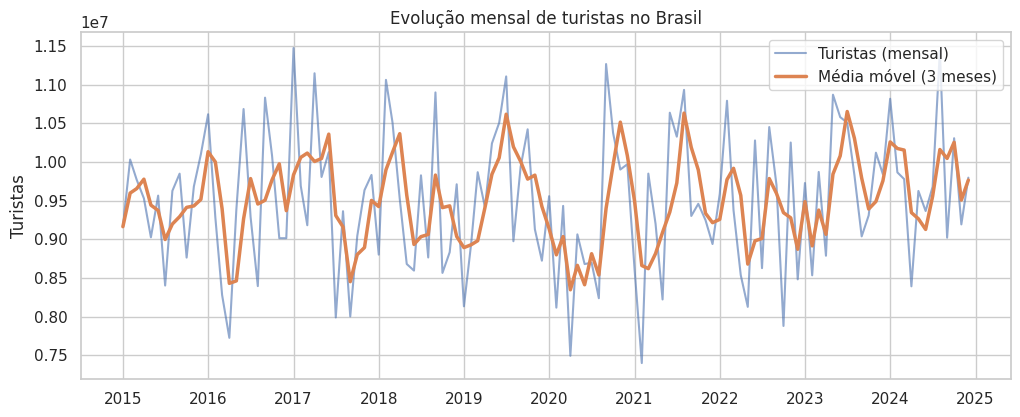

In [8]:
serie_mensal = base.groupby("data", as_index=False)["turistas"].sum()
serie_mensal["media_movel_3m"] = serie_mensal["turistas"].rolling(3, min_periods=1).mean()

plt.figure(figsize=(12, 4.5))
sns.lineplot(data=serie_mensal, x="data", y="turistas", label="Turistas (mensal)", alpha=0.6)
sns.lineplot(data=serie_mensal, x="data", y="media_movel_3m", label="Média móvel (3 meses)", linewidth=2.5)
plt.title("Evolução mensal de turistas no Brasil")
plt.xlabel("")
plt.ylabel("Turistas")
salvar_grafico("01_evolucao_temporal.png")
plt.show()

In [9]:
anual = base.groupby("ano", as_index=False).agg(turistas=("turistas", "sum"), faturamento=("faturamento_turismo", "sum"))
anual["crescimento_pct"] = anual["turistas"].pct_change() * 100
anual

,ano,turistas,faturamento,crescimento_pct
0,2015,113516859,"44,511,490,774.85",NaN
1,2016,112607784,"44,632,212,524.08",-0.80
2,2017,115300319,"43,365,372,714.84",2.39
3,2018,113785088,"43,150,236,402.86",-1.31
4,2019,115411649,"45,584,022,172.65",1.43
5,2020,110801442,"45,175,979,026.71",-3.99
6,2021,112133858,"43,835,357,064.14",1.20
7,2022,112096396,"44,811,773,823.29",-0.03
8,2023,117024552,"43,777,062,468.29",4.40
9,2024,117291035,"44,381,837,556.14",0.23


### 8.2 Comparação entre regiões

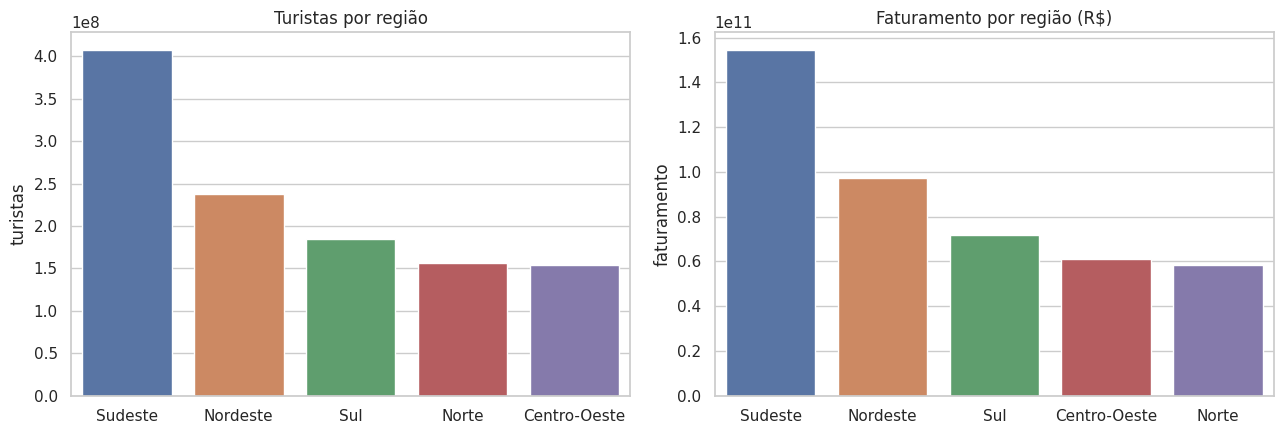

,regiao,turistas,faturamento,ocupacao
3,Sudeste,407792869,"154,613,305,825.33",60.42
1,Nordeste,237156281,"97,272,512,183.51",59.91
4,Sul,184475467,"71,726,939,783.31",60.82
2,Norte,156141154,"58,573,127,227.60",60.59
0,Centro-Oeste,154403211,"61,039,459,508.10",60.66


In [10]:
por_regiao = base.groupby("regiao", as_index=False).agg(
    turistas=("turistas", "sum"), faturamento=("faturamento_turismo", "sum"), ocupacao=("ocupacao_hoteleira", "mean")
).sort_values("turistas", ascending=False)

figura, eixos = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=por_regiao, x="regiao", y="turistas", hue="regiao", legend=False, ax=eixos[0])
eixos[0].set_title("Turistas por região")
eixos[0].set_xlabel("")
sns.barplot(data=por_regiao.sort_values("faturamento", ascending=False), x="regiao", y="faturamento",
            hue="regiao", legend=False, ax=eixos[1])
eixos[1].set_title("Faturamento por região (R$)")
eixos[1].set_xlabel("")
plt.tight_layout()
salvar_grafico("02_turistas_por_regiao.png")
plt.show()
por_regiao

### 8.3 Comparação entre cidades e ranking de destinos

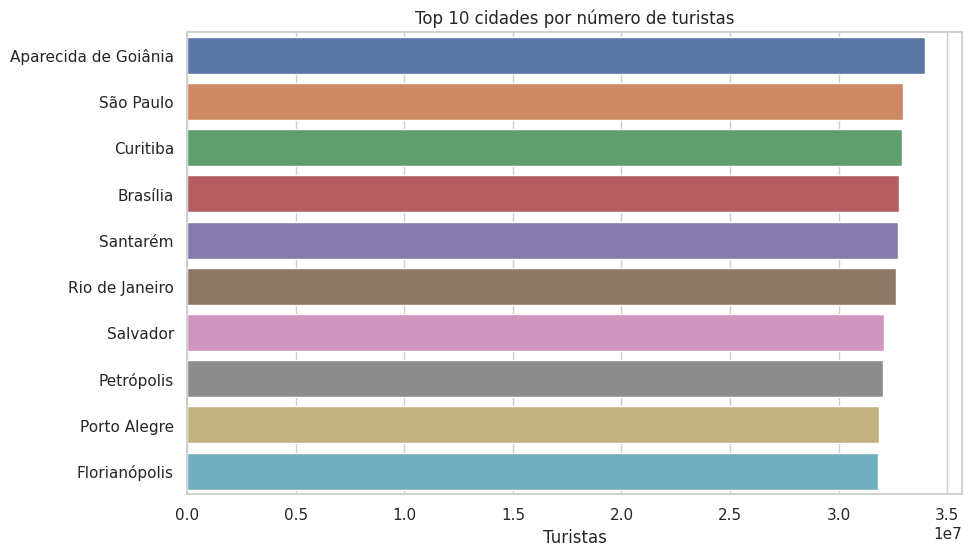

,cidade,uf,turistas,faturamento,ocupacao
0,Aparecida de Goiânia,GO,33992911,"12,151,974,506.03",60.12
33,São Paulo,SP,32977721,"11,382,315,610.92",62.22
8,Curitiba,PR,32919180,"11,278,256,416.23",58.92
3,Brasília,DF,32777402,"13,240,291,009.81",60.50
30,Santarém,PA,32714147,"11,510,582,199.04",62.52
28,Rio de Janeiro,RJ,32650630,"11,611,601,924.51",60.49
29,Salvador,BA,32087845,"12,445,314,931.39",56.64
23,Petrópolis,RJ,32041055,"12,565,014,044.58",60.81
24,Porto Alegre,RS,31845298,"11,759,426,899.66",58.43
10,Florianópolis,SC,31813471,"12,526,282,389.80",63.04


In [11]:
ranking = (
    base.groupby(["cidade", "uf"], as_index=False)
    .agg(turistas=("turistas", "sum"), faturamento=("faturamento_turismo", "sum"), ocupacao=("ocupacao_hoteleira", "mean"))
    .sort_values("turistas", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=ranking.head(10), y="cidade", x="turistas", hue="cidade", legend=False)
plt.title("Top 10 cidades por número de turistas")
plt.xlabel("Turistas")
plt.ylabel("")
salvar_grafico("03_top_cidades.png")
plt.show()
ranking.head(10)

### 8.4 Destinos com maior crescimento

In [12]:
primeiro_ano, ultimo_ano = base["ano"].min(), base["ano"].max()
comparativo = base[base["ano"].isin([primeiro_ano, ultimo_ano])].pivot_table(
    index="cidade", columns="ano", values="turistas", aggfunc="sum"
).dropna()
comparativo["crescimento_pct"] = (comparativo[ultimo_ano] / comparativo[primeiro_ano] - 1) * 100
comparativo = comparativo.sort_values("crescimento_pct", ascending=False)
comparativo.head(10)

ano,2015,2024,crescimento_pct
cidade,,,
Uberlândia,2471390,4029367,63.04
Aparecida de Goiânia,2687180,4199574,56.28
Fortaleza,2058766,3031617,47.25
Vitória,2238943,3231300,44.32
Cuiabá,2459627,3541142,43.97
Porto Velho,2616813,3619348,38.31
Londrina,2702982,3460582,28.03
Salvador,3073180,3789296,23.30
Brasília,2851151,3465623,21.55


### 8.5 Sazonalidade: mapa de calor mensal

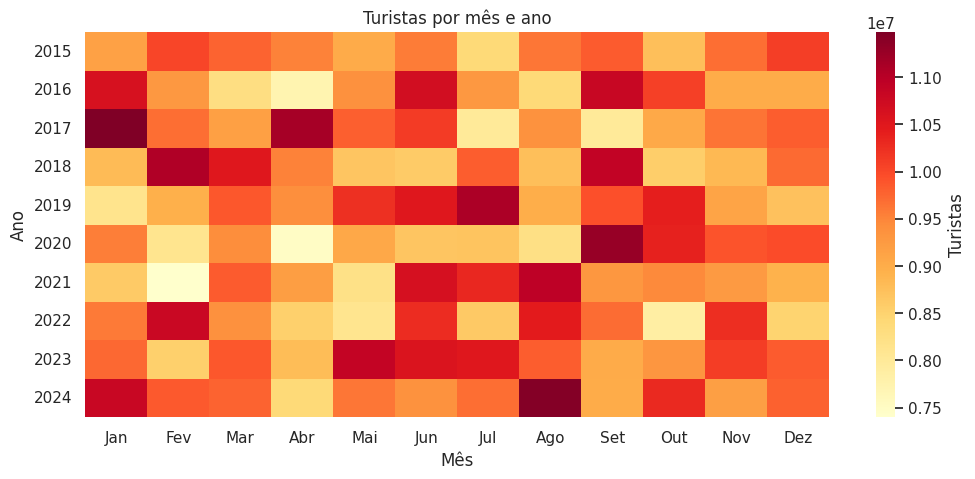

In [13]:
mapa_calor = base.pivot_table(index="ano", columns="mes", values="turistas", aggfunc="sum")
mapa_calor.columns = [nomes_meses[m] for m in mapa_calor.columns]

plt.figure(figsize=(12, 5))
sns.heatmap(mapa_calor, cmap="YlOrRd", annot=False, cbar_kws={"label": "Turistas"})
plt.title("Turistas por mês e ano")
plt.xlabel("Mês")
plt.ylabel("Ano")
salvar_grafico("04_mapa_calor_sazonalidade.png")
plt.show()

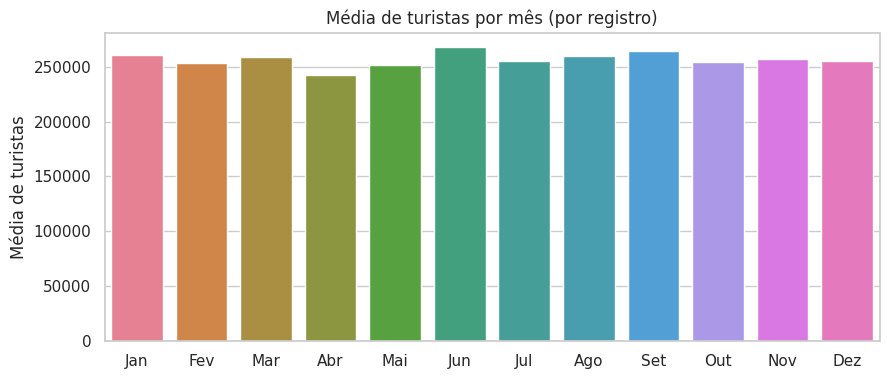

                 count        sum       mean
nivel_temporada                             
Baixa             1463  382264528 261,288.13
Média             1525  386857445 253,677.01
Alta              1452  370847009 255,404.28


In [14]:
media_mensal = base.groupby(["mes", "nome_mes"], as_index=False)["turistas"].mean().sort_values("mes")

plt.figure(figsize=(10, 4))
sns.barplot(data=media_mensal, x="nome_mes", y="turistas", hue="nome_mes", legend=False)
plt.title("Média de turistas por mês (por registro)")
plt.xlabel("")
plt.ylabel("Média de turistas")
plt.show()

print(base.groupby("nivel_temporada", observed=True)["turistas"].agg(["count", "sum", "mean"]))

### 8.6 Impacto econômico: turistas × faturamento

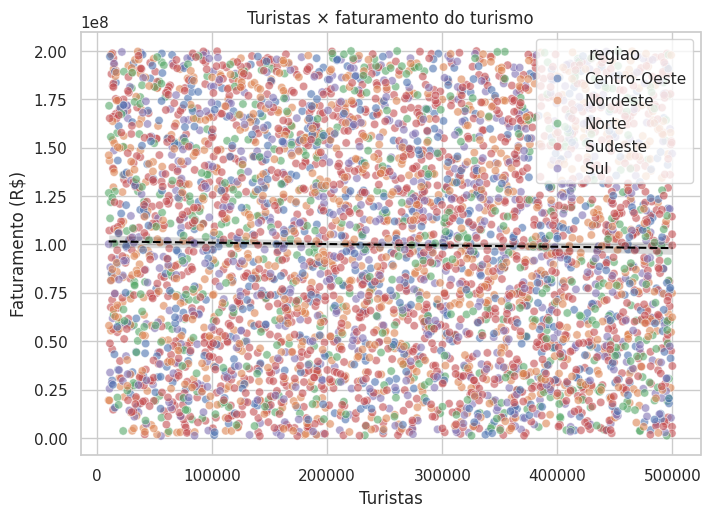

Correlação de Pearson (turistas × faturamento): -0.02


In [15]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=base, x="turistas", y="faturamento_turismo", hue="regiao", alpha=0.6)
sns.regplot(data=base, x="turistas", y="faturamento_turismo", scatter=False, color="black",
            line_kws={"linestyle": "--", "linewidth": 1.5})
plt.title("Turistas × faturamento do turismo")
plt.xlabel("Turistas")
plt.ylabel("Faturamento (R$)")
salvar_grafico("05_turistas_x_faturamento.png")
plt.show()

correlacao_receita = base["turistas"].corr(base["faturamento_turismo"])
print(f"Correlação de Pearson (turistas × faturamento): {correlacao_receita:.2f}")

### 8.7 Relação entre clima e turismo

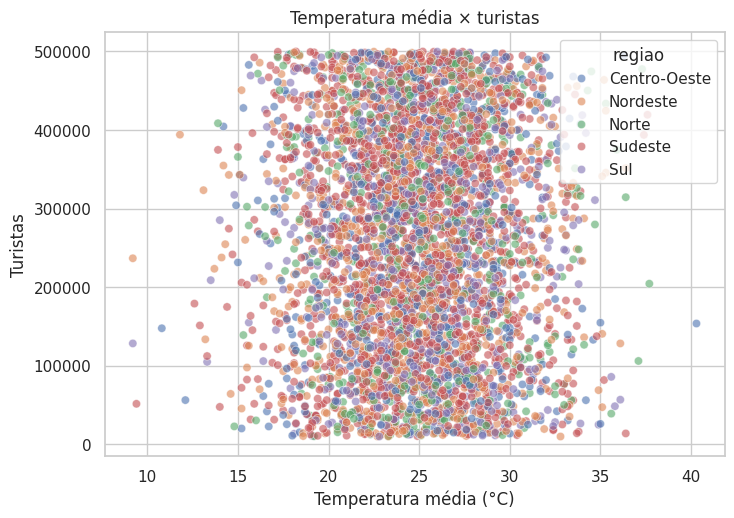

Correlação de Pearson (temperatura × turistas): -0.01


In [16]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=base, x="temperatura_media", y="turistas", hue="regiao", alpha=0.6)
plt.title("Temperatura média × turistas")
plt.xlabel("Temperatura média (°C)")
plt.ylabel("Turistas")
plt.show()

correlacao_clima = base["temperatura_media"].corr(base["turistas"])
print(f"Correlação de Pearson (temperatura × turistas): {correlacao_clima:.2f}")

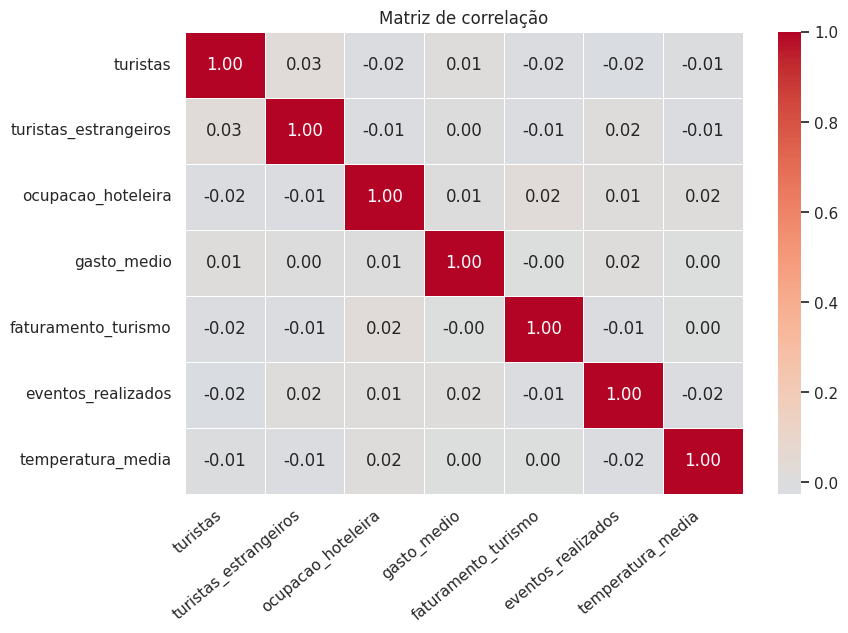

In [17]:
matriz = base[colunas_numericas].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de correlação")
plt.xticks(rotation=40, ha="right")
salvar_grafico("06_correlacao.png")
plt.show()

### 8.8 Ocupação hoteleira

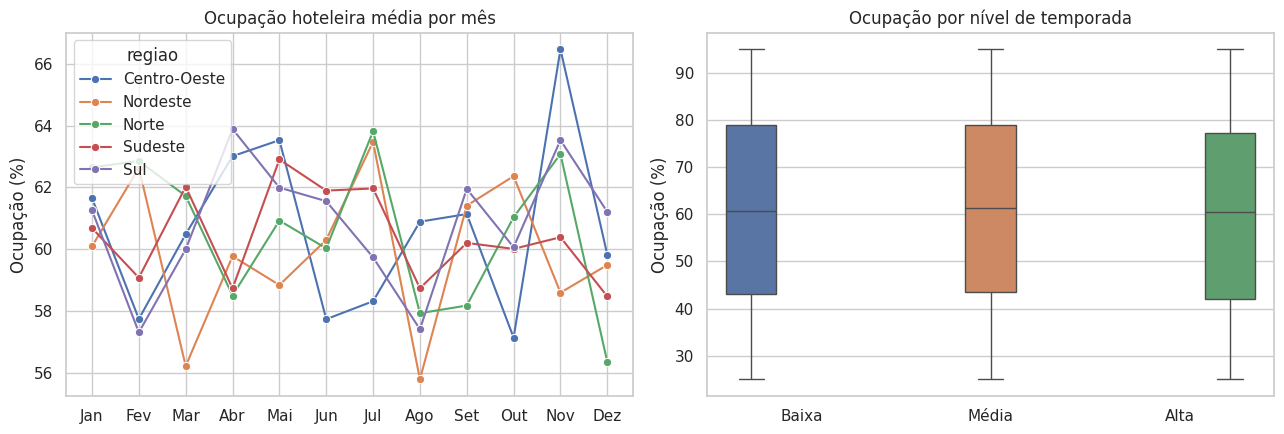

In [18]:
figura, eixos = plt.subplots(1, 2, figsize=(13, 4.5))
ocupacao_mensal = base.groupby(["mes", "nome_mes", "regiao"], as_index=False)["ocupacao_hoteleira"].mean().sort_values("mes")
sns.lineplot(data=ocupacao_mensal, x="nome_mes", y="ocupacao_hoteleira", hue="regiao", marker="o", ax=eixos[0])
eixos[0].set_title("Ocupação hoteleira média por mês")
eixos[0].set_xlabel("")
eixos[0].set_ylabel("Ocupação (%)")
sns.boxplot(data=base, x="nivel_temporada", y="ocupacao_hoteleira", hue="nivel_temporada", legend=False, ax=eixos[1])
eixos[1].set_title("Ocupação por nível de temporada")
eixos[1].set_xlabel("")
eixos[1].set_ylabel("Ocupação (%)")
plt.tight_layout()
plt.show()

### 8.9 Visualização interativa (Plotly)

In [19]:
evolucao_regiao = base.groupby(["ano", "regiao"], as_index=False)["turistas"].sum()
figura = px.line(evolucao_regiao, x="ano", y="turistas", color="regiao", markers=True,
                 title="Evolução anual de turistas por região",
                 labels={"turistas": "Turistas", "ano": "Ano", "regiao": "Região"},
                 template="plotly_white")
figura.show()

### 8.10 Tabela dinâmica

In [20]:
tabela_dinamica = base.pivot_table(index="regiao", columns="trimestre", values="turistas", aggfunc="sum")
tabela_dinamica.style.format("{:,.0f}")

trimestre,T1,T2,T3,T4
regiao,,,,
Centro-Oeste,"39,525,488","36,888,904","40,099,967","37,888,852"
Nordeste,"57,567,041","58,854,818","60,057,771","60,676,651"
Norte,"42,010,897","35,548,910","41,326,767","37,254,580"
Sudeste,"100,359,069","105,586,627","99,795,600","102,051,573"
Sul,"46,690,464","44,951,721","47,060,666","45,772,616"


## 9. Persistência em banco de dados (SQLAlchemy + SQLite)

A base tratada é gravada em um banco SQLite, que é o mesmo usado pelo dashboard Streamlit.

In [21]:
pasta_banco = Path("../database") if Path("../database").exists() else Path("database")
pasta_banco.mkdir(exist_ok=True)
motor = create_engine(f"sqlite:///{pasta_banco / 'turismo.db'}")

base.assign(nivel_temporada=base["nivel_temporada"].astype(str)).to_sql("turismo", motor, if_exists="replace", index=False)

consulta = """
    SELECT regiao, SUM(turistas) AS turistas, ROUND(AVG(ocupacao_hoteleira), 1) AS ocupacao_media
    FROM turismo
    GROUP BY regiao
    ORDER BY turistas DESC
"""
pd.read_sql(consulta, motor)

,regiao,turistas,ocupacao_media
0,Sudeste,407792869,60.40
1,Nordeste,237156281,59.90
2,Sul,184475467,60.80
3,Norte,156141154,60.60
4,Centro-Oeste,154403211,60.70


## 10. Interpretação dos resultados

O texto abaixo é gerado a partir dos números calculados, então se mantém correto caso a base seja atualizada.

In [22]:
mes_pico = media_mensal.sort_values("turistas", ascending=False).head(3)["nome_mes"].tolist()
mes_vale = media_mensal.sort_values("turistas").iloc[0]["nome_mes"]
regiao_receita = por_regiao.sort_values("faturamento", ascending=False).iloc[0]["regiao"]
destaque_crescimento = comparativo.index[0]
melhor_ano = anual.loc[anual["turistas"].idxmax()]
pior_ano = anual.loc[anual["turistas"].idxmin()]
ocupacao_temporada = base.groupby("nivel_temporada", observed=True)["ocupacao_hoteleira"].mean()

def classificar(r):
    if abs(r) < 0.2:
        return "praticamente nula"
    intensidade = "forte" if abs(r) >= 0.7 else "moderada" if abs(r) >= 0.4 else "fraca"
    return f"{intensidade} {'positiva' if r > 0 else 'negativa'}"

amplitude_sazonal = (media_mensal["turistas"].max() - media_mensal["turistas"].min()) / media_mensal["turistas"].mean() * 100
media_nivel = base.groupby("nivel_temporada", observed=True)["turistas"].mean()

print(f"1. Destinos: {turistas_por_cidade.index[0]} é a cidade mais visitada ({turistas_por_cidade.iloc[0]:,.0f} turistas), "
      f"e {destaque_crescimento} teve o maior crescimento entre {primeiro_ano} e {ultimo_ano} "
      f"({comparativo.iloc[0]['crescimento_pct']:.1f}%).")
if amplitude_sazonal >= 15:
    print(f"2. Alta temporada: os meses de maior movimento médio são {', '.join(mes_pico)}; o mais fraco é {mes_vale} "
          f"(diferença de {amplitude_sazonal:.1f}% da média: sazonalidade relevante).")
else:
    print(f"2. Alta temporada: o mês mais forte é {mes_pico[0]} e o mais fraco é {mes_vale}, mas a diferença é de apenas "
          f"{amplitude_sazonal:.1f}% da média mensal: há pouca sazonalidade nesta base.")
if media_nivel["Alta"] <= media_nivel["Baixa"]:
    print(f"   Atenção: o rótulo 'nivel_temporada' não acompanha o volume (média na Alta: {media_nivel['Alta']:,.0f}; "
          f"na Baixa: {media_nivel['Baixa']:,.0f}).")
if turistas_por_regiao.index[0] == regiao_receita:
    print(f"3. Regiões: {regiao_receita} lidera tanto em turistas quanto em faturamento.")
else:
    print(f"3. Regiões: {turistas_por_regiao.index[0]} lidera em turistas e {regiao_receita} lidera em faturamento.")
print(f"4. Impacto econômico: o setor somou R$ {receita_total:,.0f}, com gasto médio de R$ {gasto_medio:,.2f} por turista; "
      f"a correlação turistas × faturamento é {classificar(correlacao_receita)} (r = {correlacao_receita:.2f}).")
print(f"5. Evolução: o maior fluxo anual foi em {int(melhor_ano['ano'])} e o menor em {int(pior_ano['ano'])}.")
print(f"6. Clima: a correlação temperatura × turistas é {classificar(correlacao_clima)} (r = {correlacao_clima:.2f}).")
if {"Alta", "Baixa"}.issubset(ocupacao_temporada.index):
    dif_ocupacao = ocupacao_temporada["Alta"] - ocupacao_temporada["Baixa"]
    print(f"7. Hotelaria: ocupação média de {ocupacao_temporada['Alta']:.1f}% na alta temporada contra "
          f"{ocupacao_temporada['Baixa']:.1f}% na baixa ({dif_ocupacao:+.1f} p.p.).")

1. Destinos: Aparecida de Goiânia é a cidade mais visitada (33,992,911 turistas), e Uberlândia teve o maior crescimento entre 2015 e 2024 (63.0%).
2. Alta temporada: o mês mais forte é Jun e o mais fraco é Abr, mas a diferença é de apenas 9.8% da média mensal: há pouca sazonalidade nesta base.
   Atenção: o rótulo 'nivel_temporada' não acompanha o volume (média na Alta: 255,404; na Baixa: 261,288).
3. Regiões: Sudeste lidera tanto em turistas quanto em faturamento.
4. Impacto econômico: o setor somou R$ 443,225,344,528, com gasto médio de R$ 678.05 por turista; a correlação turistas × faturamento é praticamente nula (r = -0.02).
5. Evolução: o maior fluxo anual foi em 2024 e o menor em 2020.
6. Clima: a correlação temperatura × turistas é praticamente nula (r = -0.01).
7. Hotelaria: ocupação média de 59.8% na alta temporada contra 60.6% na baixa (-0.8 p.p.).


## 11. Conclusão

Os achados abaixo são gerados a partir dos números calculados neste notebook.

In [23]:
por_regiao_receita = base.groupby("regiao")[["faturamento_turismo", "turistas"]].sum()
receita_por_turista = (por_regiao_receita["faturamento_turismo"] / por_regiao_receita["turistas"]).sort_values()

print("O que os dados mostram")
print(f"- Volume: {total_turistas:,.0f} turistas no período, com {turistas_por_cidade.index[0]} como cidade mais visitada "
      f"e {turistas_por_regiao.index[0]} como região mais movimentada.")
print(f"- Economia: receita total de R$ {receita_total:,.0f} e gasto médio de R$ {gasto_medio:,.2f} por turista.")
print(f"- Relação turistas x receita: correlação {classificar(correlacao_receita)} (r = {correlacao_receita:.2f}).")
if amplitude_sazonal >= 15:
    print(f"- Sazonalidade: relevante (diferença de {amplitude_sazonal:.1f}% entre o mês mais forte e o mais fraco), "
          f"com pico em {', '.join(mes_pico)}.")
else:
    print(f"- Sazonalidade: pequena (diferença de {amplitude_sazonal:.1f}% entre o mês mais forte e o mais fraco); "
          "o fluxo é bem distribuído ao longo do ano.")
print(f"- Clima: correlação {classificar(correlacao_clima)} com o número de turistas (r = {correlacao_clima:.2f}).")
print(f"- Crescimento: {destaque_crescimento} foi o destino que mais cresceu entre {primeiro_ano} e {ultimo_ano}.")

print("\nRecomendações")
if amplitude_sazonal >= 15:
    print(f"1. Reforçar campanhas e capacidade hoteleira nos meses de pico ({', '.join(mes_pico)}) e criar ações de atração para a baixa temporada.")
else:
    print("1. Como o fluxo é bem distribuído ao longo do ano, planejar a capacidade de forma mais uniforme e investigar fatores locais (eventos, clima regional) que expliquem as diferenças entre cidades.")
print(f"2. Acompanhar {destaque_crescimento} e os demais destinos de maior crescimento como oportunidades de investimento.")
print(f"3. Comparar a receita por turista entre regiões: {receita_por_turista.index[-1]} tem o maior valor "
      f"(R$ {receita_por_turista.iloc[-1]:,.2f}) e {receita_por_turista.index[0]} o menor (R$ {receita_por_turista.iloc[0]:,.2f}).")

O que os dados mostram
- Volume: 1,139,968,982 turistas no período, com Aparecida de Goiânia como cidade mais visitada e Sudeste como região mais movimentada.
- Economia: receita total de R$ 443,225,344,528 e gasto médio de R$ 678.05 por turista.
- Relação turistas x receita: correlação praticamente nula (r = -0.02).
- Sazonalidade: pequena (diferença de 9.8% entre o mês mais forte e o mais fraco); o fluxo é bem distribuído ao longo do ano.
- Clima: correlação praticamente nula com o número de turistas (r = -0.01).
- Crescimento: Uberlândia foi o destino que mais cresceu entre 2015 e 2024.

Recomendações
1. Como o fluxo é bem distribuído ao longo do ano, planejar a capacidade de forma mais uniforme e investigar fatores locais (eventos, clima regional) que expliquem as diferenças entre cidades.
2. Acompanhar Uberlândia e os demais destinos de maior crescimento como oportunidades de investimento.
3. Comparar a receita por turista entre regiões: Nordeste tem o maior valor (R$ 410.16) e No

**Limitações:** a base é simulada, portanto os resultados ilustram o método de análise e não representam
estatísticas oficiais do turismo brasileiro. Correlação não implica causalidade, e uma correlação próxima de
zero indica que as variáveis, nesta base, não variam juntas.

**Próximo passo:** o mesmo tratamento e as mesmas métricas alimentam o dashboard interativo em Streamlit
(`app.py`), com filtros por ano, mês, região, estado, cidade e nível de temporada.